In [1]:
print("gello")

gello


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# enlever les lignes vides
Liste_features_simple = ["Sex",
                         "Age"	, # poly lineariser sur 0 1
                         "Time H-ICU"	,
                         "TIME SYMPTOMES-ICU"	,
                         "Time  DG-ICU", 
                         "Hem_mal"	,# a transformer par dic
                         "Dis_status HEM" ,# a transformer par dic
                         "HSCT_BMT",#dicoto allo auto
                         "GvHD"	, # ?
                         "Sys_dis",
                         "Solid_tumor"	,
                         "Organ_transpl"	,
                         #"Organ_transpl_spec"	,# peut se faire
                         "Drug_induced"	, # enlever les " "
                         "Chemotherapy"	,# enlever les " "
                         "Ibr_Flu_Met"	,
                         "Immuno_drugs"	,
                         "Tar_ther"	,
                         "Immunotherapy"	,
                         "Carttcells"	,
                         "Steroids_YN",
                         "Prophylaxis_pneumocystis",
                         "Prophylaxis_antifungal",
                         "Prophylaxis_bacterial"	,
                         "Prophylaxis_viral",
                         "Vaccins#Flu",
                         "Vaccins#COVID",
                         "Vaccins#Other",
                         "SOFA_score", # lineariser
                         "Resp_rate", # faire un score catégoriser avec intubation/Sp02
                         "SpO2",
                         "Temp", #a linéariser
                         "PaO2/FiO2 VALUE VALUE", # linéariser
                         "Neutrophils", #a catégoriser + clean
                         "Leukocytes",

]
features_radiology_dysfunction = ["Alveolar_xray",
                      	"Interst_xray",
                        "Pleural_eff",
                        "Quad_no",
                    	"Excavation",
                        "Fibrosis"	,
                        "Nodules"	,
                        "Pneumothorax"	,
                        "Cardiomegaly",
                        'Septal_line'	,
                        'CT_Pleural_eff'	,
                        'Halo_sign'	,
                        'CT_Excavation'	,
                        'CT_nodules#Centrolobular'	,
                        'CT_nodules#Peribronchovascular'	,
                        'CT_nodules#Pleural'	,
                        'Alveolar_cons'	,
                        'Ground_glass_op'	,
                        'Pulmonary_embolism'	,
                        'Crazy_paving'	,
                        'Bronchiectasis'	,
                        'Lymph_bulky',
                        "Vasopressors",
                        "Septic_shock"

]



# Charger le fichier Excel
df = pd.read_excel('E:/EFRAIM3 JD VANCE.xlsx')
# statistiques
features_etiology =[
                    'Etiology_Bacterial infection_Definitive diagnosis',
                    'Etiology_Viral infection_Definitive diagnosis',
                    'Etiology_Invasive pulmonary aspergillosis_Definitive diagnosis',
                    'Etiology_Pneumocystis jirovecii infection_Definitive diagnosis',
                    'Etiology_Mucorales_Definitive diagnosis',
                    'Etiology_Other fungal (specify below)_Definitive diagnosis',
                    'Etiology_Other infection (specify below)_Definitive diagnosis',
                    'Etiology_Cardiogenic pulmonary oedema_Definitive diagnosis',
                    'Etiology_Drug related_Definitive diagnosis',
                    'Etiology_Disease-related infiltrates_Definitive diagnosis',
                    'Etiology_Transfusion-related acute lung injury_Definitive diagnosis',
                    'Etiology_Other causes (specify below)_Definitive diagnosis',
                    'Etiology_Undetermined cause_Definitive diagnosis'
                    ]

df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')
Liste_features = Liste_features_simple + features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]


In [20]:
import sys
sys.modules.pop('utils.feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

sys.modules.pop('utils.visualisation', None)
sys.modules.pop('evaluation.evaluation', None)
sys.modules.pop('utils.data_aug', None)
sys.modules.pop('utils.models_and_metrics', None) 

<module 'utils.models_and_metrics' from 'c:\\Users\\phili\\Desktop\\codes\\aphp\\respiratory_diagnostics\\utils\\models_and_metrics.py'>

In [4]:

from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)

✅ Nettoyage terminé. NaN restants : 0


In [5]:
# L = df_features_clean.columns
# print(L)
print(df_features_clean.dtypes)

Sex                   float64
Time H-ICU            float64
TIME SYMPTOMES-ICU    float64
Time  DG-ICU          float64
Sys_dis               float64
                       ...   
SOFA_scaled           float64
Sa02                  float64
Resp_severity         float64
Temp_gravité          float64
Neutropenie           float64
Length: 75, dtype: object


In [6]:
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
df_features_clean = nettoyer_lignes_vides(df_features_clean)

Nombre de lignes totalement vides : 2164
Nombre de lignes totalement vides : 0
Nombre de lignes totalement vides : 0


# Mapping classes

In [7]:
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'Other fungal' :["Other fungal (specify below)","Mucorales"] ,
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug related' : ['Drug related'],
                    'Other causes': ['Other causes (specify below)','Other infection (specify below)','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
print(df_cat_clean.columns)
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")

Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Pneumocystis jirovecii infection',
       'Mucorales', 'Other fungal (specify below)',
       'Other infection (specify below)', 'Cardiogenic pulmonary oedema',
       'Drug related', 'Disease-related infiltrates',
       'Transfusion-related acute lung injury',
       'Other causes (specify below)'],
      dtype='object')


# Model 1 classe

In [ ]:
from sklearn.metrics import f1_score
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,train_and_optimize_threshold_PR
from utils.models_and_metrics import compare_models_metric
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from utils.algo_prediction import preparer_jeu_xy

from utils.algo_prediction import AutoStandardScaler
from utils.models_and_metrics import get_models,get_metric,f1_metric_xgb,negative_predictive_value
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve
from utils.models_and_metrics import get_models,get_metric
model_name = "XGBoost"
for col in df_labels_fusion.columns:
    print("==== Traitement de la colonne :", col)
    
    # print(col, df_labels_fusion[col].sum())
    df_labels_1 = df_labels_fusion[col].to_frame()
    # 2) Séparation X/y + split
    X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_1)  # ou fournir la liste

    models = get_models(y_train,use_catboost=False)
    augmentations = get_augmentation_methods(random_state=0)
    # print(augmentations.keys())


    pipe_train = Pipeline([
        ("scaler", AutoStandardScaler()),
        ("augmentation", augmentations['SMOTE']),
        ("model",models[model_name] )
    ])
    pipe_train.set_params(model__eval_metric=f1_metric_xgb)


    pipe_train.fit(X_train, y_train)

    metrics = get_metric()
    print(metrics.keys())
    metric_fn=metrics['roc_auc']["metric_fn"]
    needs_proba=metrics['roc_auc']["needs_proba"]


    pipe_test = Pipeline([
        ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
        ("model", pipe_train.named_steps["model"])     # modèle déjà fit
    ])
    if needs_proba:
        y_pred = pipe_test.predict_proba(X_test)[:, 1]
    else:
        y_pred = pipe_test.predict(X_test)
        
    score = metric_fn(y_test, y_pred)
    show_roc_curve(y_test, y_pred)
    # y_pred = (y_pred >= 0.5).astype(int)
    # show_metrics_binary(y_test, y_pred)
    
    
    
    print("Negative Predictive Value:", negative_predictive_value(y_test, y_pred))


# Multioutput


📊 Répartition des classes : pos=0.148, neg=0.852
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

🏷️ Mode MULTILABEL activé (MultiOutputClassifier)
dict_keys(['No Augmentation', 'RandomOverSampler', 'SMOTE', 'BorderlineSMOTE', 'ADASYN', 'RandomUnderSampler', 'SMOTEENN', 'SMOTETomek'])
dict_keys(['accuracy', 'precision', 'recall', 'f1', 'f_beta', 'negative_predictive_value', 'roc_auc', 'pr_auc', 'logloss', 'brier', 'at_least_one_correct', 'reject_n_lowest_correct'])
Model: Logistic Regression
Model: Random Forest


KeyboardInterrupt: 

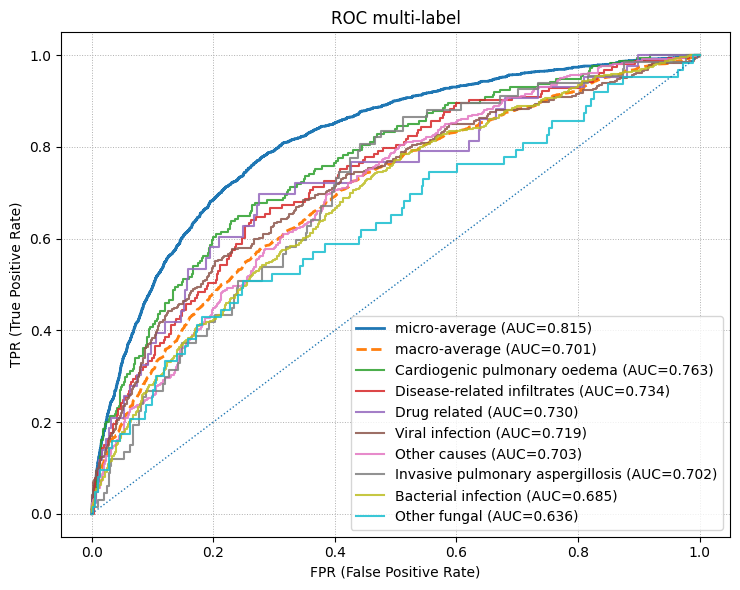

In [18]:
from imblearn.pipeline import Pipeline
from utils.algo_prediction import preparer_jeu_xy

from utils.algo_prediction import AutoStandardScaler
from utils.models_and_metrics import get_models,get_metric,f1_metric_xgb
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve
from utils.models_and_metrics import negative_predictive_value
from sklearn.metrics import (roc_auc_score)
from utils.visualisation import multilabel_roc
import numpy as np
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_fusion) 

models = get_models(y_train,multilabel=True,imbalance_threshold=0.01,use_catboost=False)
augmentations = get_augmentation_methods(random_state=0)
print(augmentations.keys())

metrics = get_metric()
print(metrics.keys())

results = []
metrique = f1_metric_xgb
for model_name, model in models.items():
    print("Model:", model_name)
    
    pipe_train = Pipeline([
        ("scaler", AutoStandardScaler()),
        # ("augmentation", augmentations['SMOTE']),
        ("model",model )
    ])
    # Changement de la métrique plus tard
    # pipe_train.set_params(model__eval_metric=f1_metric_xgb)


    pipe_train.fit(X_train, y_train)

    metric_fn=metrics['roc_auc']["metric_fn"]
    needs_proba=metrics['roc_auc']["needs_proba"]


    pipe_test = Pipeline([
        ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
        ("model", pipe_train.named_steps["model"])     # modèle déjà fit
    ])

    if needs_proba:
        y_pred = pipe_test.predict_proba(X_test)
    else:
        y_pred = pipe_test.predict(X_test)
    probas_array = np.column_stack([p[:, 1] for p in y_pred])

    a = multilabel_roc(
        np.array(y_test), probas_array,
        plot=True,
        label_names=y_test.columns.to_list(),
        per_label_max=8,   # ne tracer que les 8 meilleures courbes par label
        show_micro=True,
        show_macro=True
        )

    # score = roc_auc_score(y_test, y_pred, average="macro")
    # show_metrics_binary(y_test, y_pred)
    # show_roc_curve(y_test, y_pred)
    # print("Negative Predictive Value:", negative_predictive_value(y_test, y_pred))

In [21]:
from utils.models_and_metrics import get_models_multilabel, compare_models_metric, get_metric
from sklearn.metrics import hamming_loss
from sklearn.metrics import f1_score
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,train_and_optimize_threshold_PR
# Charger les mod?les multilabel sp?cialis?s
models = get_models_multilabel()

metrics = get_metric()
# print(metrics['f1']'metric_fn')
# Pr?parer les donn?es
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_fusion)

# Comparer avec une m?trique multilabel
df_scores = compare_models_metric(
    models,
    metric_fn=f1_score,  # ou f1_score avec un autre average
    metric_kwargs={"average": "weighted"},
    metric_name="f1_weighted",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    needs_proba=False
)

print(df_scores)



🏷️ Mode MULTILABEL spécialisé : 7 modèles chargés


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.5s finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conve

⚠️ MLkNN : erreur during training → ignoré.
'DataFrame' object has no attribute 'getformat'


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.9s finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conve


🏆 CLASSEMENT DES MODÈLES PAR F1_WEIGHTED :

                   Modèle  f1_weighted
0             XGBoost OVR     0.356920
5          Label Powerset     0.355293
3       Classifier Chains     0.305704
2  Logistic Regression BR     0.300135
1       Random Forest OVR     0.296605
4                   RAkEL     0.294989
                   Modèle  f1_weighted
0             XGBoost OVR     0.356920
5          Label Powerset     0.355293
3       Classifier Chains     0.305704
2  Logistic Regression BR     0.300135
1       Random Forest OVR     0.296605
4                   RAkEL     0.294989


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.0min finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


# SHAP values

In [ ]:
sys.modules.pop('utils.feature_importance', None)
from utils.feature_importance import shap_top10_per_estimator,plot_top10_features_per_estimator
plot_top10_features_per_estimator(modele,feature_names=X_train.columns,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/importance')
shap_top10_per_estimator(model= modele,X = X_test_sc,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/shap')

In [ ]:
from utils.stats_dataset import analyze_collinearity
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
Liste_features = Liste_features_simple #+ features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
df_col_utils = _convert_all_columns_to_numeric(df_col_utils)
# print(df_col_utils.columns)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
vif_results = analyze_collinearity(df_col_utils)
vif_results_clean = analyze_collinearity(df_features_clean)




In [ ]:
df_col_utils.isna().any().any()
# print(df_features_clean.isna().sum()[df_features_clean.isna().sum() > 0])


In [ ]:
L_radio = ['Alveolar_xray_No', 'Alveolar_xray_Focal',
       'Alveolar_xray_Diffuse', 'Interst_xray_No', 'Interst_xray_Focal',
       'Interst_xray_Diffuse', 'Alveolar_cons_No', 'Alveolar_cons_Focal',
       'Alveolar_cons_Diffuse', 'Ground_glass_op_No', 'Ground_glass_op_Focal',
       'Ground_glass_op_Diffuse', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'SOFA_scaled', 'Sa02', 'Resp_severity',
       'Temp_gravité', 'Neutropenie']
for x in L_radio:
    print(df_features_clean[x].value_counts())

In [ ]:
df_features_clean.iloc[0]

In [ ]:
Implémenter from sklearn.model_selection import StratifiedKFold
